# KDE Plots Testing Notebook

This notebook is for manual testing of KDE (Kernel Density Estimation) quartile plots.
It uses functions from `postprocess_functions.py` and `plot_kde_functions.py`.

In [15]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

from ddstartup.postprocessing.postprocess_functions import (
    load_h5_to_dataframe,
    get_input_parameters,
    scale_target,
    apply_filters,
    find_latest_h5_file
)
from ddstartup.postprocessing.plot_kde_functions import kde_quartile_plot
from ddstartup.utils.tools import PARAM_UNITS

print("✅ Imports successful")

✅ Imports successful


## Configuration

In [16]:
# Configuration - specify directory or files

# Option 1: Automatic - find latest file in specified directory (DEFAULT)
outputs_dir = Path('../outputs')
files_to_analyze = []

latest_h5_file = find_latest_h5_file(outputs_dir)
if latest_h5_file:
    print(f"📂 Auto-detected folder: {latest_h5_file.parent.name}")
    print(f"📄 Latest file: {latest_h5_file.name}")
    files_to_analyze = [latest_h5_file]

# Option 2: Analyze all files in a specific folder
# outputs_dir = Path('../outputs/20251008_081422_parametric_T_seeded')
# files_to_analyze = sorted(outputs_dir.glob('*.h5'))
# print(f"📂 Using folder: {outputs_dir.name}")
# print(f"📄 Found {len(files_to_analyze)} file(s): {[f.name for f in files_to_analyze]}")

# Option 3: Manually specify exact file(s)
# files_to_analyze = [
#     Path('../outputs/20251008_081422_parametric_T_seeded/parametric_T_seeded.h5'),
#     Path('../outputs/20251007_143015_parametric_lump/parametric_lump.h5'),
# ]
# print(f"📄 Manually specified {len(files_to_analyze)} file(s)")

if files_to_analyze:
    print(f"\n✅ Will analyze {len(files_to_analyze)} file(s)")
else:
    print("⚠️  No files specified")

# Target variables to analyze
target_variables = ['unrealized_gains', 't_startup']

# Optional filters (set to {} for no filtering)
input_filters = {}  # e.g., {'V_plasma': {'min': None, 'max': 150}}
output_filters = {}  # e.g., {'unrealized_gains': {'min': 2e6, 'max': None}}

📂 Auto-detected folder: 20251008_081422_parametric_T_seeded
📄 Latest file: ddstartup_20251008_081422_parametric_T_seeded.h5

✅ Will analyze 1 file(s)


In [17]:
# Loop through all files to analyze
for file_idx, selected_file in enumerate(files_to_analyze, 1):
    print(f"\n{'#'*80}")
    print(f"# FILE {file_idx}/{len(files_to_analyze)}: {selected_file.name}")
    print(f"{'#'*80}\n")
    
    # Load HDF5 data
    print(f"Loading data from {selected_file.name}...")
    df = load_h5_to_dataframe(selected_file)

    print(f"\n📊 Dataset info:")
    print(f"   Rows: {len(df):,}")
    print(f"   Columns: {len(df.columns)}")
    print(f"\n   Available columns: {list(df.columns)}")


################################################################################
# FILE 1/1: ddstartup_20251008_081422_parametric_T_seeded.h5
################################################################################

Loading data from ddstartup_20251008_081422_parametric_T_seeded.h5...

📊 Dataset info:
   Rows: 256
   Columns: 34

   Available columns: ['E_lost', 'I_target', 'N_ifc', 'N_ofc', 'N_stor', 'P_DDn', 'P_DDp', 'P_DT', 'P_DT_eq', 'P_aux', 'P_aux_DT_eq', 'Q_DD', 'Q_DT_eq', 'TBE', 'TBR_DDn', 'TBR_DT', 'T_i', 'V_plasma', 'capacity_factor', 'cost_of_electricity', 'error', 'eta_th', 'linear_index', 'n_D', 'n_He3', 'n_T', 'n_tot', 'sol_success', 't_startup', 'tau_He3', 'tau_ifc', 'tau_ofc', 'tau_p_T', 'unrealized_gains']


In [18]:
    # Determine file type for plot title
    filename = selected_file.name.lower()
    if "lump" in filename:
        file_type = "lump"
    elif "t_seeded" in filename or "tseeded" in filename:
        file_type = "Tseeded"
    else:
        file_type = "unknown"

    print(f"📝 File type: {file_type}")

📝 File type: Tseeded



🎯 Target: unrealized_gains
   Filtered: 256 → 224 rows (87.5%)

📊 Data after filtering:
   Rows: 224
   Target unit: M$
   Input parameters: ['V_plasma', 'n_tot', 'T_i', 'tau_p_T', 'P_aux', 'P_aux_DT_eq', 'tau_ifc', 'tau_ofc', 'TBR_DT', 'TBR_DDn', 'eta_th', 'capacity_factor', 'cost_of_electricity']

🎨 Generating KDE plot...


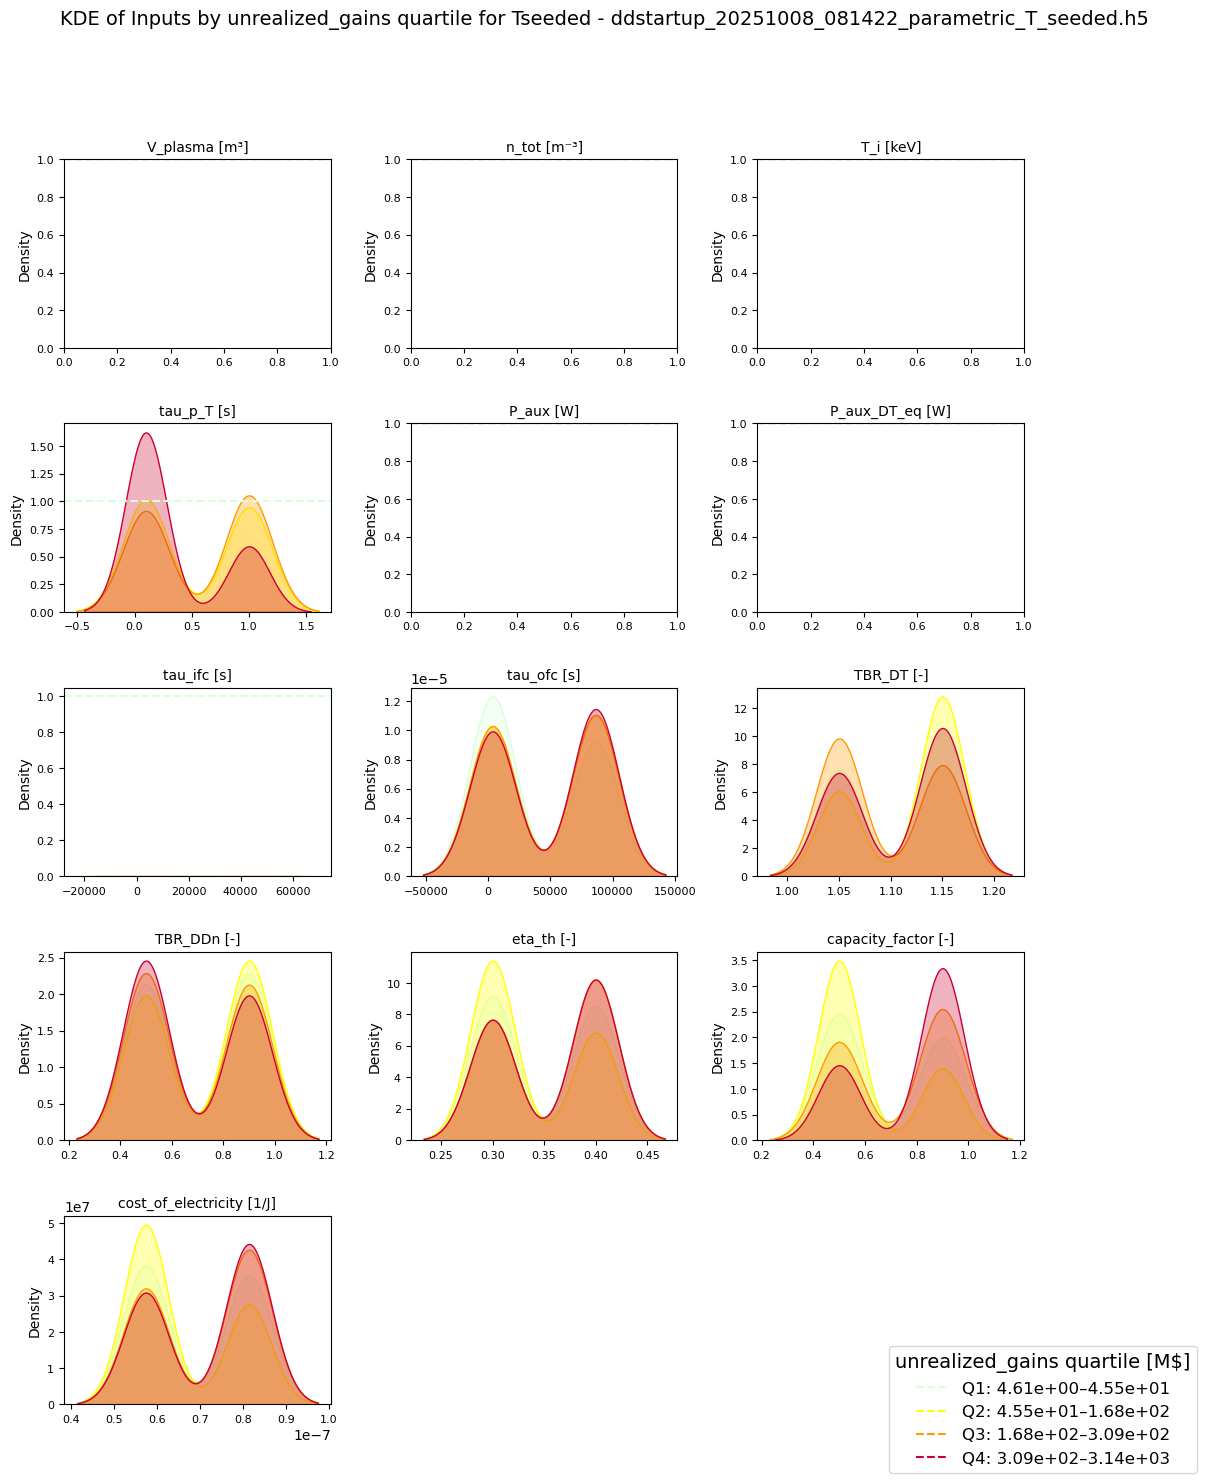

✅ Plot displayed

🎯 Target: t_startup
   Filtered: 256 → 224 rows (87.5%)

📊 Data after filtering:
   Rows: 224
   Target unit: days
   Input parameters: ['V_plasma', 'n_tot', 'T_i', 'tau_p_T', 'tau_ifc', 'tau_ofc', 'TBR_DT', 'TBR_DDn']

🎨 Generating KDE plot...


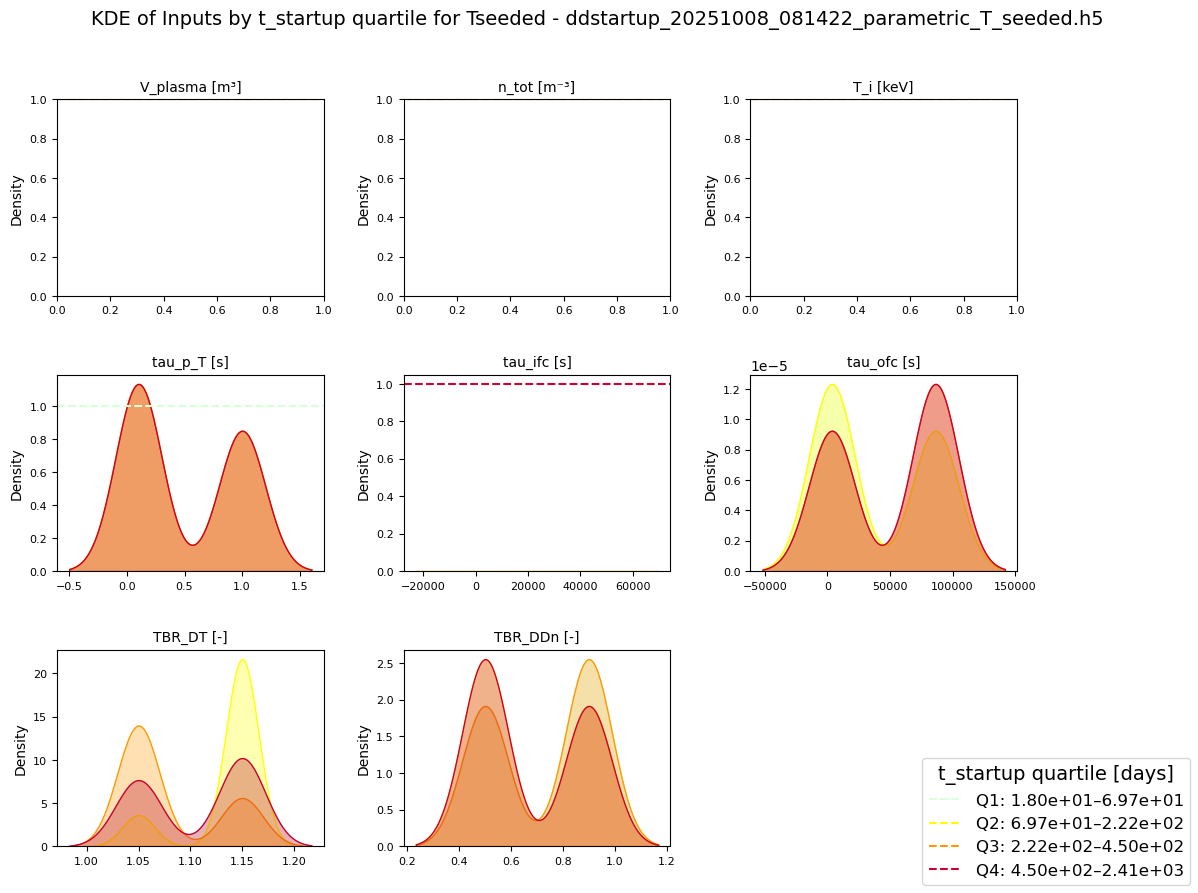

✅ Plot displayed

✅ Completed analysis for ddstartup_20251008_081422_parametric_T_seeded.h5


In [19]:
    for target in target_variables:
        if target not in df.columns:
            print(f"⚠️  Target '{target}' not found in data. Skipping.")
            continue
        
        print(f"\n{'='*60}")
        print(f"🎯 Target: {target}")
        print(f"{'='*60}")
        
        # Apply filters
        df_filtered = apply_filters(df, input_filters, output_filters, target)
        
        if len(df_filtered) == 0:
            print(f"   ⚠️  No data remaining after filtering. Skipping.")
            continue
        
        # Scale target variable
        df_filtered, target_unit = scale_target(df_filtered, target)
        
        # Get input parameters
        input_parameters = get_input_parameters(df_filtered, target, filename=str(selected_file))
        
        print(f"\n📊 Data after filtering:")
        print(f"   Rows: {len(df_filtered):,}")
        print(f"   Target unit: {target_unit}")
        print(f"   Input parameters: {input_parameters}")
        
        # Generate KDE plot (inline, not saved)
        print(f"\n🎨 Generating KDE plot...")
        
        # Modified version of kde_quartile_plot that displays inline
        n_inputs = len(input_parameters)
        if n_inputs == 0:
            print(f"   No input parameters found. Skipping.")
            continue
        
        ncols = min(3, n_inputs)
        nrows = int(np.ceil(n_inputs / ncols))
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 3*nrows), sharey=False)
        axes = axes.flatten() if n_inputs > 1 else [axes]
        
        # Quartile binning
        bin_edges = df_filtered[target].quantile([0, 0.25, 0.5, 0.75, 1.0]).values
        bin_labels = [
            f"Q1: {bin_edges[0]:.2e}–{bin_edges[1]:.2e}",
            f"Q2: {bin_edges[1]:.2e}–{bin_edges[2]:.2e}",
            f"Q3: {bin_edges[2]:.2e}–{bin_edges[3]:.2e}",
            f"Q4: {bin_edges[3]:.2e}–{bin_edges[4]:.2e}"
        ]
        df_filtered[f"{target}_bin"] = pd.qcut(df_filtered[target], q=4, labels=bin_labels)
        
        # Get colors from postprocess_functions
        from ddstartup.postprocessing.postprocess_functions import get_discrete_colorscale
        colorscale = get_discrete_colorscale(4)
        quartile_colors = [colorscale[i*2][1] for i in range(4)]
        color_map = {label: quartile_colors[i] for i, label in enumerate(bin_labels)}
        
        for i, param in enumerate(input_parameters):
            ax = axes[i]
            for bin_label in df_filtered[f"{target}_bin"].cat.categories:
                data = df_filtered.loc[df_filtered[f"{target}_bin"] == bin_label, param].dropna()
                if len(data) == 0:
                    continue
                color = color_map[bin_label]
                if np.var(data) == 0:
                    ax.axhline(1, color=color, linestyle='--', label=str(bin_label))
                else:
                    sns.kdeplot(data, fill=True, alpha=0.3, ax=ax, label=str(bin_label), color=color)
            
            # Add unit to title if available
            if param in PARAM_UNITS:
                param_label = f"{param} [{PARAM_UNITS[param]}]"
            else:
                param_label = param
            ax.set_title(param_label, fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("Density")
            ax.tick_params(labelsize=8)
        
        # Hide unused subplots
        for j in range(n_inputs, len(axes)):
            axes[j].set_visible(False)
        
        # Add legend
        handles, labels = axes[0].get_legend_handles_labels()
        legend_title = f"{target} quartile [{target_unit}]"
        fig.legend(handles, labels,
                   title=legend_title,
                   loc='lower right',
                   fontsize=12, title_fontsize=14)
        
        # Adjust layout
        fig.suptitle(f"KDE of Inputs by {target} quartile for {file_type} - {selected_file.name}", fontsize=14)
        plt.subplots_adjust(
            left=0.05,
            right=0.85,
            top=0.88,
            bottom=0.05,
            wspace=0.3,
            hspace=0.4
        )
        
        plt.show()
        print(f"✅ Plot displayed")
    
    print(f"\n✅ Completed analysis for {selected_file.name}")

## Summary Statistics

View quartile statistics for the target variables.

In [20]:
for target in target_variables:
    if target in df.columns:
        print(f"\n{target}:")
        print(df[target].describe())


unrealized_gains:
count    2.240000e+02
mean     3.798457e+08
std      6.134259e+08
min      4.611738e+06
25%      4.547346e+07
50%      1.684549e+08
75%      3.087415e+08
max      3.144280e+09
Name: unrealized_gains, dtype: float64

t_startup:
count    2.240000e+02
mean     4.508637e+07
std      6.415870e+07
min      1.557517e+06
25%      6.024942e+06
50%      1.921604e+07
75%      3.889704e+07
max      2.083342e+08
Name: t_startup, dtype: float64
